# Notebook 1 — Data Preparation & Elevation Enrichment

**Project:** *ML for energy and driving context* on the Vehicle Energy Dataset (VED) —
application to a driving assistant / adaptive cruise control.

**Purpose of this notebook:**
1. Load the VED dataset parquet files and consolidate them into a single DataFrame
2. Explore the structure, run sanity checks and handle outliers
3. Enrich the data with elevation (Open-Meteo Elevation API)
4. Compute slope and acceleration along each trip
5. Save an "enriched" parquet ready for the downstream ML notebooks

**Final output:** `ved_enriched.parquet` — consolidated dataset + elevation + slope + accel, used
by all downstream notebooks.

> To be run **only once**. The others load the output directly.
>
> *Framing note:* the elevation/slope computed here was intended as a central feature
> ("ACC exploiting orography"), but turned out to be a **weak signal** (flat Ann Arbor +
> quantization at ~111 m). The project was reframed around the anticipated speed profile;
> slope remains as a *documented data limitation*. See
> `project context/PROJECT_REPORT.md`.

## 1. Setup and imports

In [1]:
import glob
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

try:
    import truststore
    truststore.inject_into_ssl()
    print("truststore active (SSL verification via the OS trust store)")
except ImportError:
    print("truststore not installed: if API calls fail due to SSL, run 'pip install truststore'")

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')

DATA_DIR = Path("./content")

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup OK")

truststore active (SSL verification via the OS trust store)
Setup OK


## 2. Loading the parquet files

We load **all** the parquet files found in `content/` (recursively) and concatenate them into a single DataFrame.

The VED dataset on Kaggle is distributed across several weekly files with an identical schema, so concatenation is straightforward. We do not distinguish the temporal origin (Phase 1 / Phase 2): it is metadata we use neither in the supervised model nor in the clustering, and the temporal split in Notebook 2 is based on `Datetime` anyway.

In [2]:
files = sorted(glob.glob(str(DATA_DIR / "**" / "*.parquet"), recursive=True))
print(f"Found {len(files)} parquet files in {DATA_DIR}/")
if not files:
    raise FileNotFoundError(
        f"No parquet in {DATA_DIR.resolve()}. "
        "Put the VED *.parquet files inside the content/ folder."
    )

df = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)

print(f"\nConsolidated dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Found 54 parquet files in content/

Consolidated dataset: 18,258,138 rows × 18 columns
Memory: 1.59 GB


## 3. Initial inspection

Quick check of types, NaNs, temporal range, fleet size.

In [3]:
print("=== DTYPE ===")
print(df.dtypes)

print("\n=== NaN per column ===")
print(df.isna().sum())

print("\n=== Temporal range ===")
print(f"From: {df['Datetime'].min()}")
print(f"To:   {df['Datetime'].max()}")
print(f"Duration: {(df['Datetime'].max() - df['Datetime'].min()).days} days")

print("\n=== Fleet ===")
print(f"Unique vehicles:   {df['VehId'].nunique()}")
print(f"Unique trips:      {df.groupby(['VehId','Trip']).ngroups:,}")
print(f"EngineType:")
print(df['EngineType'].value_counts())

=== DTYPE ===
VehId                                       int32
Trip                                        int32
Timestampms                                 int32
Latitude_deg                              float32
Longitude_deg                             float32
Vehicle_Speed_km_per_h                    float32
MAF_g_per_sec                             float32
Engine_RPM_RPM                            float32
Absolute_Load_pct                         float32
OAT_DegC                                  float32
Short_Term_Fuel_Trim_Bank_1_pct           float32
Short_Term_Fuel_Trim_Bank_2_pct           float32
Long_Term_Fuel_Trim_Bank_1_pct            float32
Long_Term_Fuel_Trim_Bank_2_pct            float32
Datetime                           datetime64[ns]
EngineType                                    str
Generalized_Weight                        float64
log_MAF                                   float32
dtype: object

=== NaN per column ===
VehId                              0
Trip       

### 4 Outlier handling on Absolute_Load_pct

Technically `Absolute Load` can exceed 100% (it is a percentage of the maximum air flow at sea level; under turbo / downhill conditions it can go above 100). But values > 200% are almost certainly sensor errors: we clip them.

For Vehicle_Speed and RPM we apply reasonable thresholds for consumer vehicles. Always document these choices: an instructor appreciates critical thinking about real data.

In [4]:
before = len(df)

mask = (
    (df['Absolute_Load_pct'].between(0, 200)) &
    (df['Vehicle_Speed_km_per_h'].between(0, 200)) &
    (df['Engine_RPM_RPM'].between(0, 8000)) &
    (df['MAF_g_per_sec'].between(0, 300))
)

df = df[mask].copy()
after = len(df)
print(f"Removed {before - after:,} rows ({(before-after)/before*100:.3f}%)")
print(f"Dataset now: {after:,} rows")

Removed 481 rows (0.003%)
Dataset now: 18,257,657 rows


### 4.2 Spatial exploration

We confirm that the whole dataset covers the Ann Arbor (MI) area, and visualize the density of points.

Lat: [42.2203, 42.3258]
Lon: [-83.8043, -83.6740]


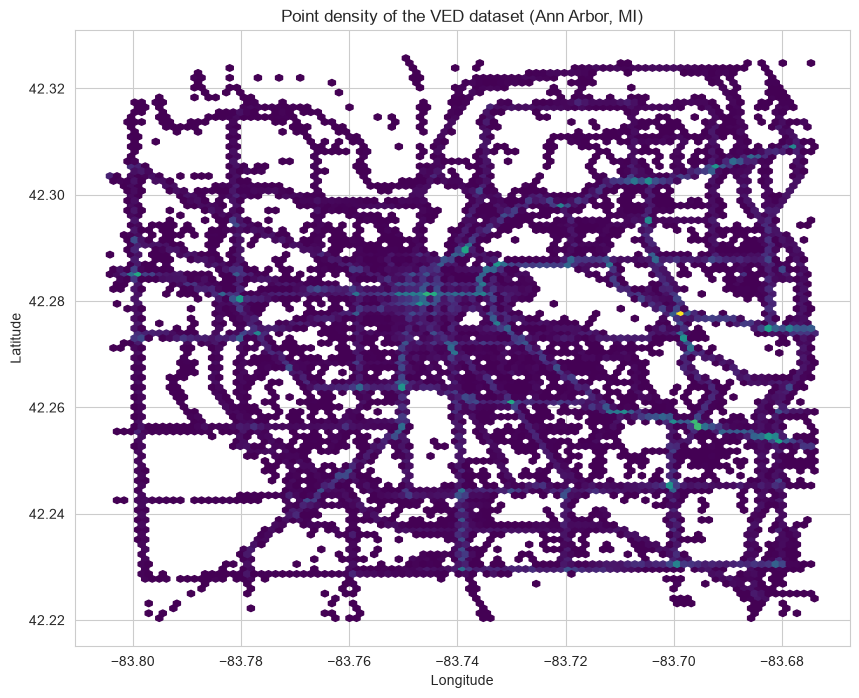

In [5]:
print(f"Lat: [{df['Latitude_deg'].min():.4f}, {df['Latitude_deg'].max():.4f}]")
print(f"Lon: [{df['Longitude_deg'].min():.4f}, {df['Longitude_deg'].max():.4f}]")

sample = df.sample(n=200_000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 8))
ax.hexbin(sample['Longitude_deg'], sample['Latitude_deg'], gridsize=100, cmap='viridis', mincnt=1)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Point density of the VED dataset (Ann Arbor, MI)')
plt.show()

## 5. Filter on valid motion

Many rows correspond to a stationary vehicle (Speed=0) or an idling engine: useful for anomaly detection but noisy for our dynamic consumption prediction task. We keep only rows with speed > 0 or RPM > 0 (engine running).

In [6]:
before = len(df)
df = df[(df['Vehicle_Speed_km_per_h'] > 0) | (df['Engine_RPM_RPM'] > 100)].copy()
print(f"After motion filter: {len(df):,} rows (removed {before-len(df):,})")

After motion filter: 17,922,869 rows (removed 334,788)


## 6. Enrichment with the Elevation API

The dataset **does not contain elevation**: we have to derive it. We use the **Open-Meteo Elevation API** (free, no API key, based on SRTM).

**Spatial dedup strategy:** instead of calling the API for every row (~18M calls, infeasible), we round the coordinates and request elevation only for the unique points.

**How many decimals?** Resolution matters. SRTM (the source behind Open-Meteo) has a resolution of **~30 m**: querying points closer than that is pure waste, because they fall into the same SRTM cell and return the same elevation. On our data:
- `round(4)` (~11 m) → ~282k unique points → ~2800 batches → **unusable** (over 45 min) *and* finer than the source;
- `round(3)` (~111 m) → ~8.7k unique points → ~88 batches → **~1-2 min**, granularity consistent with SRTM.

So we choose **3 decimals**: aligning the sampling grid with the real resolution of the data. The API supports up to 100 points per request.

In [7]:
ROUND_DECIMALS = 3
df['lat_round'] = df['Latitude_deg'].round(ROUND_DECIMALS)
df['lon_round'] = df['Longitude_deg'].round(ROUND_DECIMALS)

unique_coords = df[['lat_round', 'lon_round']].drop_duplicates().reset_index(drop=True)
print(f"Unique points to query: {len(unique_coords):,}")
print(f"Reduction vs total rows: {len(df)/len(unique_coords):.0f}×")
print(f"Batches of 100: {(len(unique_coords)+99)//100:,}")

Unique points to query: 8,705
Reduction vs total rows: 2059×
Batches of 100: 88


In [8]:
ELEVATION_CACHE = OUTPUT_DIR / "elevation_cache.parquet"

def _fetch_batch(url, params, max_retries=10, base_sleep=2.0, rate_limit_wait=60):
    """GET with patient waiting on the 429 rate-limit (respects Retry-After).
    Fail-fast on non-recoverable errors."""
    last_err = None
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, timeout=30)
            if r.status_code == 429:
                wait = int(r.headers.get('Retry-After', 0)) or rate_limit_wait
                print(f"    429 rate-limit: waiting {wait:.0f}s and retrying ({attempt+1}/{max_retries})...")
                time.sleep(wait)
                last_err = requests.HTTPError("429 Too Many Requests")
                continue
            r.raise_for_status()
            return r.json()['elevation']
        except requests.exceptions.RequestException as e:
            last_err = e
            if attempt < max_retries - 1:
                time.sleep(base_sleep * (2 ** attempt))
    raise RuntimeError(
        f"Batch failed after {max_retries} attempts: {last_err!r}\n"
        "If it is SSL (CERTIFICATE_VERIFY_FAILED): truststore not active (see setup).\n"
        "If it is 429: Open-Meteo is throttling; retry in a few minutes."
    )

def fetch_elevations(coords_df, batch_size=100, sleep_between=1.5):
    """Open-Meteo Elevation API in batches (max 100 coords/request), gentle pacing."""
    url = "https://api.open-meteo.com/v1/elevation"
    elevations = []
    n_batches = (len(coords_df) + batch_size - 1) // batch_size

    for i in range(0, len(coords_df), batch_size):
        batch = coords_df.iloc[i:i+batch_size]
        params = {
            'latitude': ','.join(map(str, batch['lat_round'].values)),
            'longitude': ','.join(map(str, batch['lon_round'].values))
        }
        elevations.extend(_fetch_batch(url, params))

        b = i // batch_size + 1
        if b % 10 == 0 or b == n_batches:
            print(f"  Progress: {b}/{n_batches} batches ({b/n_batches*100:.0f}%)")
        time.sleep(sleep_between)

    out = coords_df.copy()
    out['elevation_m'] = elevations[:len(coords_df)]
    return out

if ELEVATION_CACHE.exists():
    print("Loading from local cache...")
    cached = pd.read_parquet(ELEVATION_CACHE)
    cached = cached[cached['elevation_m'].notna()]
    elev_df = unique_coords.merge(cached, on=['lat_round', 'lon_round'], how='left')
else:
    elev_df = unique_coords.copy()
    elev_df['elevation_m'] = np.nan

missing = elev_df['elevation_m'].isna()
print(f"In cache: {(~missing).sum():,} / {len(elev_df):,} points")

if missing.any():
    print(f"Downloading {missing.sum():,} missing points from Open-Meteo...")
    fetched = fetch_elevations(elev_df.loc[missing, ['lat_round', 'lon_round']])
    elev_df.loc[missing, 'elevation_m'] = fetched['elevation_m'].values
    elev_df.to_parquet(ELEVATION_CACHE)
    print(f"Cache updated: {ELEVATION_CACHE}")

if elev_df['elevation_m'].isna().any():
    raise RuntimeError(
        f"Cache still incomplete: {elev_df['elevation_m'].isna().sum():,} points without elevation. "
        "Complete the cache (re-run this cell or build_elevation_cache.py) before continuing."
    )

print(f"\nElevations obtained: {elev_df['elevation_m'].notna().sum():,} / {len(elev_df):,}")
print(f"Elevation range: {elev_df['elevation_m'].min():.1f} – {elev_df['elevation_m'].max():.1f} m")

Loading from local cache...
In cache: 8,705 / 8,705 points

Elevations obtained: 8,705 / 8,705
Elevation range: 223.0 – 324.0 m


### 6.1 Merge elevation into the dataset

Dataset now has 17,922,869 rows with elevation (100.00%)


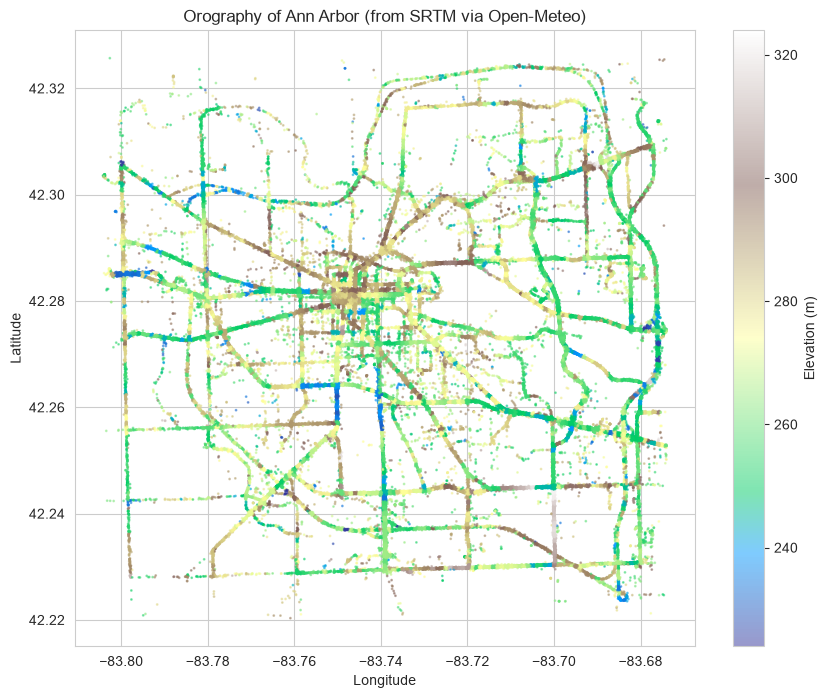

In [9]:
df = df.merge(elev_df, on=['lat_round', 'lon_round'], how='left')
print(f"Dataset now has {df['elevation_m'].notna().sum():,} rows with elevation ({df['elevation_m'].notna().mean()*100:.2f}%)")

sample = df.sample(n=100_000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(sample['Longitude_deg'], sample['Latitude_deg'],
                c=sample['elevation_m'], cmap='terrain', s=1, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Elevation (m)')
ax.set_title('Orography of Ann Arbor (from SRTM via Open-Meteo)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## 7. Slope computation

The instantaneous slope under a vehicle is obtained as:

$$\text{slope} = \frac{\Delta \text{elevation}}{\Delta \text{distance}}$$

We compute $\Delta$ between consecutive rows **within the same trip** (grouping by `VehId` + `Trip`).

For distance we use the **Haversine formula**, which computes distances on a sphere given lat/lon.

In [10]:
def haversine_vec(lat1, lon1, lat2, lon2):
    """Distance in meters between pairs of coordinates (vectorized)."""
    R = 6371000.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df = df.sort_values(['VehId', 'Trip', 'Timestampms']).reset_index(drop=True)

grp = df.groupby(['VehId', 'Trip'])
df['lat_prev'] = grp['Latitude_deg'].shift(1)
df['lon_prev'] = grp['Longitude_deg'].shift(1)
df['elev_prev'] = grp['elevation_m'].shift(1)
df['ts_prev'] = grp['Timestampms'].shift(1)

df['dist_m'] = haversine_vec(df['lat_prev'], df['lon_prev'],
                              df['Latitude_deg'], df['Longitude_deg'])
df['dz_m'] = df['elevation_m'] - df['elev_prev']
df['dt_ms'] = df['Timestampms'] - df['ts_prev']

df['slope'] = np.where(df['dist_m'] > 1.0, df['dz_m'] / df['dist_m'], 0.0)

df['slope'] = df['slope'].clip(-0.3, 0.3)

df = df.drop(columns=['lat_prev', 'lon_prev', 'elev_prev', 'ts_prev'])

print("Slope statistics (fraction, e.g. 0.05 = 5%):")
print(df['slope'].describe())
print(f"\nSlope NaN: {df['slope'].isna().sum():,} (first row of each trip)")

Slope statistics (fraction, e.g. 0.05 = 5%):
count    1.792287e+07
mean     7.662844e-06
std      5.585678e-02
min     -3.000000e-01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.000000e-01
Name: slope, dtype: float64

Slope NaN: 0 (first row of each trip)


## 8. Time-derived feature: acceleration

We compute acceleration as the derivative of speed with respect to time. Beware the **irregular sampling rate** (the time delta varies between 100ms and 1400ms): we cannot use a plain diff(), we must divide by the real time delta.

In [11]:
grp = df.groupby(['VehId', 'Trip'])
df['speed_prev'] = grp['Vehicle_Speed_km_per_h'].shift(1)
df['dv_kmh'] = df['Vehicle_Speed_km_per_h'] - df['speed_prev']

df['accel_kmh_s'] = np.where(df['dt_ms'] > 50, df['dv_kmh'] / (df['dt_ms'] / 1000.0), 0.0)

df['accel_kmh_s'] = df['accel_kmh_s'].clip(-15, 10)

df = df.drop(columns=['speed_prev', 'dv_kmh'])

print(df['accel_kmh_s'].describe())

count    1.792287e+07
mean    -1.018694e-01
std      3.917571e+00
min     -1.500000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+01
Name: accel_kmh_s, dtype: float64


## 9. Saving the enriched dataset

We save the final parquet that the downstream notebooks will load. We keep only the useful columns to reduce the file size.

In [12]:
cols_keep = [
    'VehId', 'Trip', 'Timestampms', 'Datetime',
    'Latitude_deg', 'Longitude_deg', 'elevation_m', 'slope',
    'Vehicle_Speed_km_per_h', 'accel_kmh_s',
    'Engine_RPM_RPM', 'Absolute_Load_pct',
    'MAF_g_per_sec', 'log_MAF',
    'OAT_DegC',
    'Short_Term_Fuel_Trim_Bank_1_pct', 'Long_Term_Fuel_Trim_Bank_1_pct',
    'EngineType', 'Generalized_Weight',
    'dist_m', 'dt_ms'
]

df_final = df[cols_keep].copy()

df_final = df_final.dropna(subset=['slope', 'accel_kmh_s', 'elevation_m']).reset_index(drop=True)

OUT_PATH = OUTPUT_DIR / "ved_enriched.parquet"
df_final.to_parquet(OUT_PATH, compression='snappy', index=False)

print(f"✓ Saved: {OUT_PATH}")
print(f"  Final rows: {len(df_final):,}")
print(f"  Size on disk: {OUT_PATH.stat().st_size / 1e6:.1f} MB")
print(f"  Unique trips: {df_final.groupby(['VehId','Trip']).ngroups:,}")
print(f"  Unique vehicles: {df_final['VehId'].nunique()}")

✓ Saved: outputs\ved_enriched.parquet
  Final rows: 17,922,869
  Size on disk: 378.1 MB
  Unique trips: 26,285
  Unique vehicles: 299


## 10. Final check and sanity statistics

One last quick check on the derived features, and a visualization of a sample trip to make sure slope and acceleration are sensible.

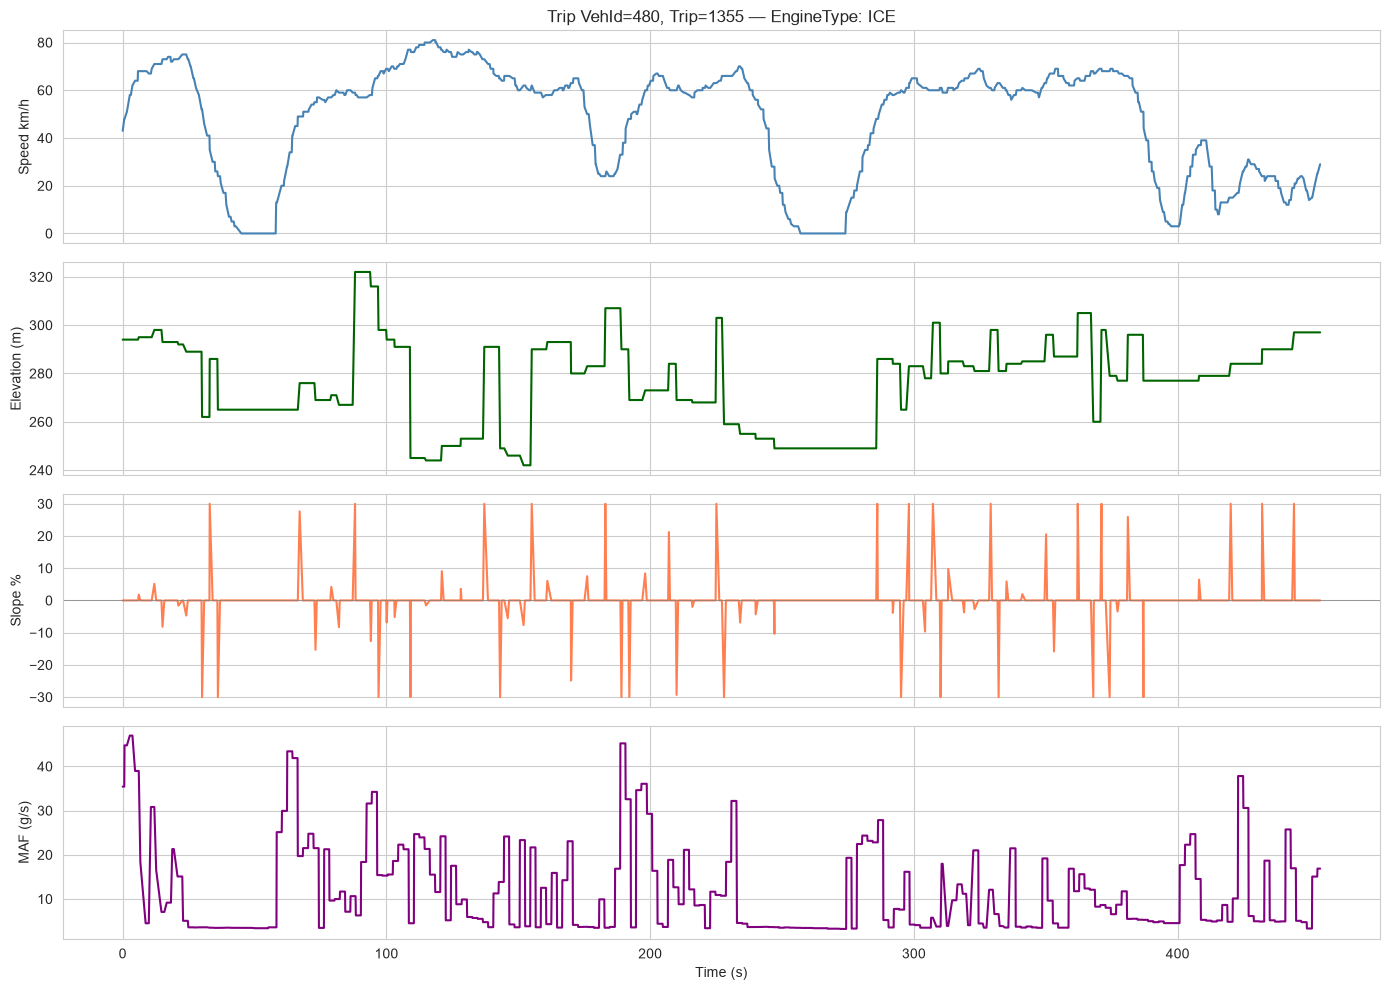

In [13]:
trip_lens = df_final.groupby(['VehId', 'Trip']).size().reset_index(name='n')
trip_lens = trip_lens[trip_lens['n'].between(500, 2000)]
veh_id, trip_id, _ = trip_lens.sample(n=1, random_state=42).iloc[0]

trip = df_final[(df_final['VehId']==veh_id) & (df_final['Trip']==trip_id)].sort_values('Timestampms')
trip['elapsed_s'] = (trip['Timestampms'] - trip['Timestampms'].iloc[0]) / 1000

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(trip['elapsed_s'], trip['Vehicle_Speed_km_per_h'], color='steelblue')
axes[0].set_ylabel('Speed km/h')
axes[0].set_title(f'Trip VehId={veh_id}, Trip={trip_id} — EngineType: {trip["EngineType"].iloc[0]}')

axes[1].plot(trip['elapsed_s'], trip['elevation_m'], color='darkgreen')
axes[1].set_ylabel('Elevation (m)')

axes[2].plot(trip['elapsed_s'], trip['slope']*100, color='coral')
axes[2].set_ylabel('Slope %')
axes[2].axhline(0, color='gray', lw=0.5)

axes[3].plot(trip['elapsed_s'], trip['MAF_g_per_sec'], color='purple')
axes[3].set_ylabel('MAF (g/s)')
axes[3].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

---

## Summary

**What we built:**
- VED dataset consolidated from all the parquet files in `content/`
- Outlier filtering (Absolute_Load > 200%, RPM > 8000, Speed > 200, MAF > 300)
- Enrichment with elevation via Open-Meteo (free, ~150 batch calls thanks to dedup)
- Slope computation via Haversine + elevation/distance derivative
- Acceleration computation handling the irregular sampling

**Output:** `outputs/ved_enriched.parquet` — ready for notebooks 2 and 3.

**Next steps:**
- Notebook 2 → supervised model to predict MAF (predictive adaptive cruise control)
- Notebook 3 → unsupervised clustering to characterize road segments